# 05 — Nearby Rental Search Prototype

Answers *“Can RoomBeacon help a user find trustworthy rentals near a place they care about?”* directly from canonical Silver — without ever faking a distance.

| | |
|---|---|
| **Objective** | Validate multi-tier nearby retrieval and measure how much of the data supports true radius search. |
| **Input** | `data/silver/rental_listings.parquet` (read-only) |
| **Output** | Ranked results and coverage evidence; CSV artifacts are written only by the last, `skip-execution` cell |
| **Invariant** | `distance_km` is computed (Haversine) **only** when both the reference point and the listing have trusted coordinates; no coordinate is inferred from a ward or district |

**Contents**

- Setup
- 01. Search configuration
- 02. Load canonical Silver
- 03. Search population & price display policy
- 04. Location quality & coordinate coverage
- 05. Reference location contract
- 06. Multi-tier retrieval & location taxonomy
- 07. Search coverage funnel
- 08. Ranked results
- 09. Radius market view (trusted-coordinate subset)
- 10. Product readiness
- 11. Persist analytical artifacts
- Summary

## Where this notebook sits

```mermaid
flowchart LR
    BR[("Bronze snapshot<br/>Parquet")] --> NB01 & NB02
    NB02 --> SV[("Silver<br/>rental_listings.parquet")]
    SV --> NB03 --> NB04 --> CH[("Locked champion<br/>LightGBM F4 RAW")]
    SV --> NB05
    CH --> NB06 & NB07
    NB01["01 · Raw EDA"]
    NB02["02 · Bronze → Silver"]
    NB03["03 · Feature contract"]
    NB04["04 · Price model"]
    NB05["05 · Nearby search"]
    NB06["06 · Shadow validation"]
    NB07["07 · Performance"]
    classDef current fill:#2a78d6,color:#ffffff,stroke:#184f95
    class NB05 current
```

The highlighted step is this notebook.

## How a search is answered

```mermaid
flowchart TD
    Q["Reference point<br/>lat/lon + optional ward/district"] --> P["Rental-compatible listings<br/>(no SALE / TRANSFER / whole building)"]
    P --> T{"Listing has a<br/>trusted coordinate?"}
    T -->|yes| E["Tier 1 · EXACT DISTANCE<br/>Haversine ≤ radius, ranked by<br/>coordinate quality then distance"]
    T -->|no| W{"Same ward?"}
    W -->|yes| SW["Tier 2 · SAME WARD<br/>distance = null"]
    W -->|no| D{"Same district?"}
    D -->|yes| SD["Tier 3 · SAME DISTRICT<br/>distance = null"]
    D -->|no| O{"Ward or district known?"}
    O -->|yes| R["Tier 4 · RESOLVED OUTSIDE AREA"]
    O -->|no| U["Tier 5 · LOCATION UNRESOLVED"]
```

Coordinate search status (`TRUSTED_CONSISTENT` → `TRUSTED_ADMIN_UNVERIFIED` → `TRUSTED_BUT_ADMIN_MISMATCH`,
`SHARED_POINT_CONFLICT`) keeps mis-pinned listings from ranking like genuine local ones.

## Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    p
    for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "crawler").is_dir() and (p / "analytics").is_dir()
)
sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.utils import setup_project_path

PROJECT_ROOT = setup_project_path()

import json
from datetime import datetime, timezone

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from analytics.duckdb.connection import resolve_runtime_path
from roombeacon_crawler.config.get_env import env
from notebooks.utils.nearby_rental_search import (
    audit_location_coverage,
    build_search_funnel,
    create_reference_location_contract,
    derive_display_price,
    evaluate_product_readiness,
    execute_nearby_rental_search,
    filter_rental_compatible,
    format_filter_range,
    summarize_radius_market,
)
from notebooks.utils.notebook_style import (
    CATEGORICAL,
    ORDINAL_BLUES,
    apply_style,
    bar_chart,
    funnel_chart,
    range_chart,
    status_chart,
)

apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}" if abs(x) < 1000 else f"{x:,.0f}")

Đã phát hiện thư mục gốc của dự án RoomBeacon: /data/projects/roombeacon/source/roombeacon-system


## 01. Search configuration

> **Why:** One place to change the reference point, radius, price policy and filters.

**Mode A** uses the exact coordinate; **Mode B** falls back to the ward/district when coordinates are missing or untrusted. `TRUSTED_ONLY` shows only `TRUSTED_EXISTING` / `TRUSTED_REPARSED` prices.

In [2]:
REFERENCE_NAME = "Đại học Bách Khoa TP.HCM (Campus Lý Thường Kiệt, Q.10)"
REFERENCE_LATITUDE = 10.7725
REFERENCE_LONGITUDE = 106.6578
# Campus address: 268 Lý Thường Kiệt, Phường 14, Quận 10. In the internal post-merger mapping the old
# Phường 14 (Quận 10) is AMBIGUOUS (Phường Diên Hồng / Phường Hòa Hưng), so no ward is forced; the
# fallback uses the district only. ("Phường Tân Bình" was formed from wards 13–15 of Quận Tân Bình.)
REFERENCE_WARD = None
REFERENCE_DISTRICT = "Quận 10"

SEARCH_RADIUS_KM = 3.0
MAX_RESULTS = 20
PRICE_DISPLAY_POLICY = "TRUSTED_ONLY"  # or "ALLOW_REVIEW_WITH_WARNING"
MIN_PRICE, MAX_PRICE = None, 10_000_000.0  # VND per month; None disables a bound
MIN_AREA, MAX_AREA = 15.0, None  # m²

display(
    pd.Series(
        {
            "Reference": REFERENCE_NAME,
            "Coordinates": f"({REFERENCE_LATITUDE:.4f}, {REFERENCE_LONGITUDE:.4f})",
            "Fallback ward / district": f"{REFERENCE_WARD or '— (not forced)'} / {REFERENCE_DISTRICT}",
            "Radius": f"{SEARCH_RADIUS_KM:.1f} km",
            "Max results": MAX_RESULTS,
            "Price display policy": PRICE_DISPLAY_POLICY,
            "Price filter": format_filter_range(MIN_PRICE, MAX_PRICE, "VNĐ"),
            "Area filter": format_filter_range(MIN_AREA, MAX_AREA, "m²"),
        },
        name="value",
    ).to_frame()
)

,value
Reference,Đại học Bách Khoa TP.HCM (Campus Lý Thường Kiệ...
Coordinates,"(10.7725, 106.6578)"
Fallback ward / district,— (not forced) / Quận 10
Radius,3.0 km
Max results,20
Price display policy,TRUSTED_ONLY
Price filter,"None - 10,000,000 VNĐ"
Area filter,15 - Unlimited m²


## 02. Load canonical Silver

> **Why:** Search reads the canonical Silver file only; it never depends on Bronze or mutates Silver.

In [3]:
SILVER_PATH = resolve_runtime_path(env.processing.silver_dir) / "rental_listings.parquet"
METADATA_PATH = SILVER_PATH.parent / "rental_listings.metadata.json"
assert SILVER_PATH.exists(), f"Canonical Silver not found at {SILVER_PATH}"
with duckdb.connect(":memory:") as con:
    silver_df = con.execute("SELECT * FROM read_parquet(?)", [str(SILVER_PATH)]).df()

assert (
    len(silver_df) > 0
    and silver_df["rental_post_id"].notna().all()
    and silver_df["rental_post_id"].is_unique
)
if METADATA_PATH.exists():
    assert len(silver_df) == json.loads(METADATA_PATH.read_text(encoding="utf-8"))["row_count"]
display(
    pd.Series(
        {"Rows": f"{len(silver_df):,}", "Columns": len(silver_df.columns)}, name="value"
    ).to_frame()
)

,value
Rows,"132,494"
Columns,80


## 03. Search population & price display policy

> **Why:** Search only ordinary rentals and never show an unverified price as if it were verified.

Excludes explicit `SALE`/`TRANSFER` intent and whole-building or multi-unit business listings; keeps `UNKNOWN` when nothing conflicts.

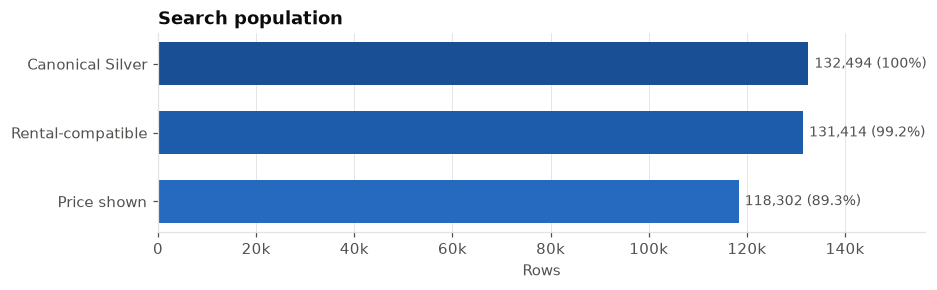

,Listings
price_display_status,
TRUSTED,118302
REVIEW_EXCLUDED,8239
MISSING,4249
SUSPECT_UNIT_SCALE,624


In [4]:
rental_df = filter_rental_compatible(silver_df)
rental_df = derive_display_price(rental_df, price_display_policy=PRICE_DISPLAY_POLICY)

funnel_chart(
    pd.Series(
        {
            "Canonical Silver": len(silver_df),
            "Rental-compatible": len(rental_df),
            "Price shown": int(rental_df["price_display_status"].eq("TRUSTED").sum()),
        }
    ),
    title="Search population",
)
plt.show()
rental_df["price_display_status"].value_counts().to_frame("Listings")

## 04. Location quality & coordinate coverage

> **Why:** Measure how much of the data can support true radius search today.

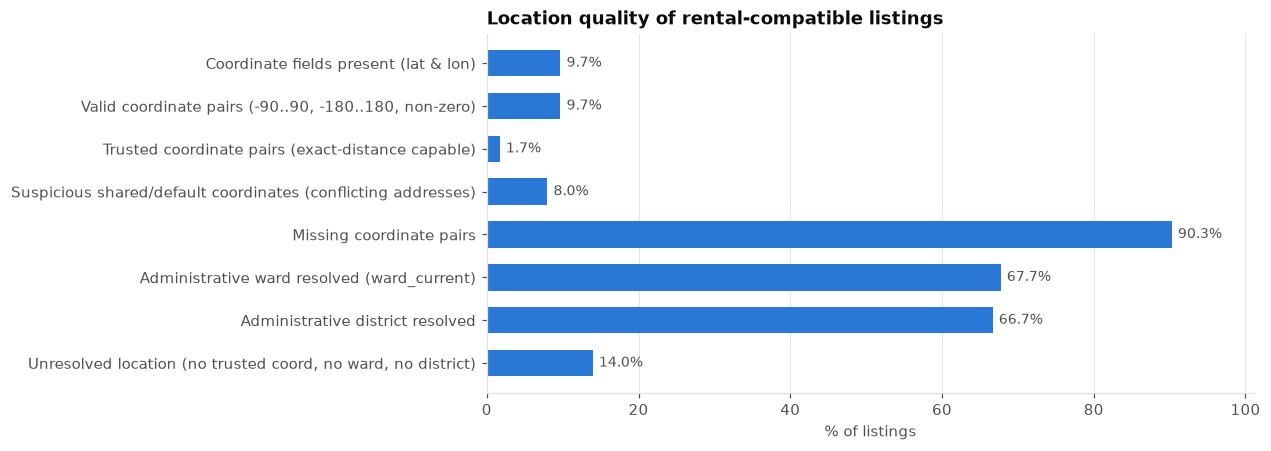


**Finding:** only **1.72%** (2,255) of listings have a trusted coordinate, and
**7.99%** (10,505) sit on shared/default pins with conflicting addresses. In
contrast **67.74%** (89,023) have a resolved ward. RoomBeacon is therefore an
**administrative-location retrieval system with a small high-precision radius tier**.


In [5]:
coverage_audit = audit_location_coverage(rental_df)
coverage = coverage_audit.set_index("Metric")["Percent"].drop("Total rental-compatible listings")
bar_chart(
    coverage,
    title="Location quality of rental-compatible listings",
    xlabel="% of listings",
    sort=False,
    fmt="{:.1f}%",
)
plt.show()

metric = coverage_audit.set_index("Metric")
trusted = metric.loc["Trusted coordinate pairs (exact-distance capable)"]
hotspot = metric.loc["Suspicious shared/default coordinates (conflicting addresses)"]
ward = metric.loc["Administrative ward resolved (ward_current)"]
display(
    Markdown(
        f"""
**Finding:** only **{trusted.Percent:.2f}%** ({int(trusted.Count):,}) of listings have a trusted coordinate, and
**{hotspot.Percent:.2f}%** ({int(hotspot.Count):,}) sit on shared/default pins with conflicting addresses. In
contrast **{ward.Percent:.2f}%** ({int(ward.Count):,}) have a resolved ward. RoomBeacon is therefore an
**administrative-location retrieval system with a small high-precision radius tier**.
"""
    )
)

## 05. Reference location contract

> **Why:** Be explicit about what is known about the reference point; no reverse-geocoding is faked.

In [6]:
ref_contract = create_reference_location_contract(
    name=REFERENCE_NAME,
    latitude=REFERENCE_LATITUDE,
    longitude=REFERENCE_LONGITUDE,
    ward=REFERENCE_WARD,
    district=REFERENCE_DISTRICT,
)
display(
    pd.Series(
        {
            "Admin verification": ref_contract["reference_admin_verification_status"],
            "Exact-distance capable": ref_contract["is_exact_distance_capable"],
            "Fallback ward": ref_contract["reference_ward"],
            "Fallback district": ref_contract["reference_district"],
            "Ward ↔ district check": ref_contract["reference_admin_consistency"],
        },
        name="value",
    ).to_frame()
)
assert (
    ref_contract["reference_admin_consistency"] != "WARD_NOT_IN_DISTRICT"
), "Reference ward does not belong to the reference district"
display(
    Markdown(
        "Administrative labels stay `USER_SUPPLIED_UNVERIFIED`: no GIS polygons are bundled, so they "
        "are not presented as verified."
    )
)

,value
Admin verification,USER_SUPPLIED_UNVERIFIED
Exact-distance capable,True
Fallback ward,None
Fallback district,Quận 10
Ward ↔ district check,NOT_APPLICABLE


Administrative labels stay `USER_SUPPLIED_UNVERIFIED`: no GIS polygons are bundled, so they are not presented as verified.

## 06. Multi-tier retrieval & location taxonomy

> **Why:** Run the five-tier search and partition every listing into exactly one location state.

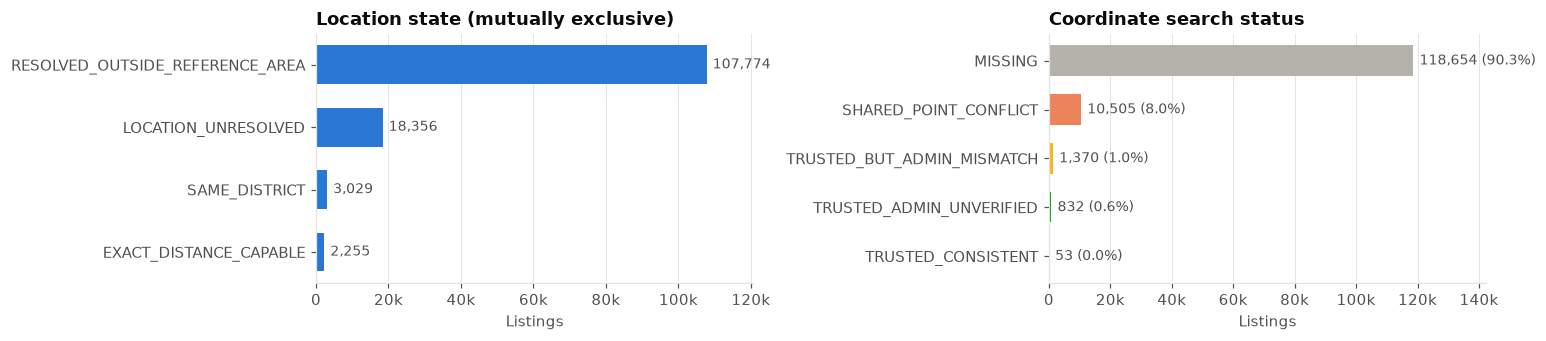

In [7]:
exact_results, same_ward_results, same_district_results, search_df = execute_nearby_rental_search(
    rental_df,
    reference_latitude=REFERENCE_LATITUDE,
    reference_longitude=REFERENCE_LONGITUDE,
    reference_ward=REFERENCE_WARD,
    reference_district=REFERENCE_DISTRICT,
    radius_km=SEARCH_RADIUS_KM,
    min_price=MIN_PRICE,
    max_price=MAX_PRICE,
    min_area=MIN_AREA,
    max_area=MAX_AREA,
    max_results=MAX_RESULTS,
    price_display_policy=PRICE_DISPLAY_POLICY,
)
taxonomy_counts = search_df["location_match_type"].value_counts()
coord_quality = search_df["coordinate_search_status"].value_counts()

fig, (left, right) = plt.subplots(1, 2, figsize=(14, 3.2))
bar_chart(taxonomy_counts, title="Location state (mutually exclusive)", xlabel="Listings", ax=left)
status_chart(
    coord_quality,
    tiers={
        "TRUSTED_CONSISTENT": "good",
        "TRUSTED_ADMIN_UNVERIFIED": "good",
        "TRUSTED_BUT_ADMIN_MISMATCH": "warning",
        "SHARED_POINT_CONFLICT": "serious",
    },
    title="Coordinate search status",
    xlabel="Listings",
    ax=right,
)
plt.tight_layout()
plt.show()

## 07. Search coverage funnel

> **Why:** Follow the population from all rentals down to the radius tiers and fallbacks.

In [8]:
funnel_df = build_search_funnel(search_df, radius_km=SEARCH_RADIUS_KM)
display(funnel_df)

,Category,Stage,Count,Share % (Total),Share % (Exact)
0,Total Population,1. Rental-compatible listings,131414,100.00,100.00
1,Search Taxonomy (Mutually Exclusive),├── Exact-distance capable (trusted coords),2255,1.72,100.00
2,Search Taxonomy (Mutually Exclusive),├── Fallback: Same Ward matches,0,0.00,0.00
3,Search Taxonomy (Mutually Exclusive),├── Fallback: Same District matches,3029,2.30,0.00
4,Search Taxonomy (Mutually Exclusive),├── Resolved outside reference area,107774,82.01,0.00
5,Search Taxonomy (Mutually Exclusive),"└── Location unresolved (no coords, no admin)",18356,13.97,0.00
6,Exact Radius Reach,2. Exact distance <= 10 km,1866,1.42,82.75
7,Exact Radius Reach,3. Exact distance <= 5 km,833,0.63,36.94
8,Exact Radius Reach,4. Exact distance <= 3 km,287,0.22,12.73
9,Exact Radius Reach,5. Exact distance <= 1 km,31,0.02,1.37


## 08. Ranked results

> **Why:** What a user would actually see: exact-distance results first, then administrative fallbacks.

In [9]:
cols_to_show = [
    "rental_post_id",
    "source_code",
    "title_clean",
    "display_price",
    "price_display_status",
    "area_value_clean",
    "ward_current",
    "district_text_extracted",
    "coordinate_search_status",
    "distance_km",
    "distance_band",
    "location_match_type",
]


def show_results(title, frame, limit):
    display(Markdown(f"**{title}** — {len(frame):,} matches"))
    display(frame[cols_to_show].head(limit) if len(frame) else Markdown("*No listings matched.*"))


show_results(
    f"Exact distance ≤ {SEARCH_RADIUS_KM:.1f} km (ranked by coordinate quality, then distance)",
    exact_results,
    MAX_RESULTS,
)
show_results(
    f"Fallback: same ward ({REFERENCE_WARD or 'not configured'}) — distance unavailable",
    same_ward_results,
    10,
)
show_results(
    f"Fallback: same district ({REFERENCE_DISTRICT}) — distance unavailable",
    same_district_results,
    10,
)

**Exact distance ≤ 3.0 km (ranked by coordinate quality, then distance)** — 20 matches

,rental_post_id,source_code,title_clean,display_price,price_display_status,area_value_clean,ward_current,district_text_extracted,coordinate_search_status,distance_km,distance_band,location_match_type
24116,84749,mogi,"phòng trọ q10, giờ tự do, khoá vân tay, tầng trệt","4,000,000",TRUSTED,20.00,NaN,Quận 10,TRUSTED_CONSISTENT,0.22,<= 1 km,EXACT_DISTANCE_CAPABLE
41391,105477,mogi,Cho thuê duplex cửa sổ không giới hạn người ở ...,"5,000,000",TRUSTED,25.00,NaN,Quận 10,TRUSTED_CONSISTENT,0.49,<= 1 km,EXACT_DISTANCE_CAPABLE
12131,70894,mogi,Cho thuê phòng tách bếp Full nội thất ở Nguyễn...,"4,000,000",TRUSTED,20.00,NaN,Quận 10,TRUSTED_CONSISTENT,0.81,<= 1 km,EXACT_DISTANCE_CAPABLE
22763,83230,cafeland,Phòng trọ: Phòng trọ đẹp mặt tiền đường Đồng N...,"2,800,000",TRUSTED,18.00,Phường Hòa Hưng,Quận 10,TRUSTED_CONSISTENT,0.92,<= 1 km,EXACT_DISTANCE_CAPABLE
19965,80001,cafeland,Phòng trọ: Trống phòng ban công mới 100% dạng ...,"6,000,000",TRUSTED,30.00,Phường Hòa Hưng,Quận 10,TRUSTED_CONSISTENT,0.92,<= 1 km,EXACT_DISTANCE_CAPABLE
23069,83556,mogi,"Phòng trọ ký túc xá quận 10 máy lạnh, trọn gói...","950,000",TRUSTED,250.00,NaN,Quận 10,TRUSTED_CONSISTENT,0.95,<= 1 km,EXACT_DISTANCE_CAPABLE
23081,83568,mogi,"Phòng trọ ký túc xá quận 10 ngay big C, tự do,...","950,000",TRUSTED,250.00,NaN,Quận 10,TRUSTED_CONSISTENT,1.08,1–3 km,EXACT_DISTANCE_CAPABLE
46034,112715,mogi,Căn hộ 1PN ban công cửa sổ siêu thoáng gần trư...,"5,000,000",TRUSTED,35.00,Phường Hòa Hưng,Quận 10,TRUSTED_CONSISTENT,1.16,1–3 km,EXACT_DISTANCE_CAPABLE
46082,112763,mogi,Cho thuê studio cửa sổ siêu thoáng gần trường ...,"5,000,000",TRUSTED,30.00,Phường Vườn Lài,Quận 10,TRUSTED_CONSISTENT,1.26,1–3 km,EXACT_DISTANCE_CAPABLE
24940,85683,cafeland,Phòng trọ: Phòng studio ban công rộng trung tâ...,"7,500,000",TRUSTED,35.00,Phường Hòa Hưng,Quận 10,TRUSTED_CONSISTENT,1.32,1–3 km,EXACT_DISTANCE_CAPABLE


**Fallback: same ward (not configured) — distance unavailable** — 0 matches

*No listings matched.*

**Fallback: same district (Quận 10) — distance unavailable** — 20 matches

,rental_post_id,source_code,title_clean,display_price,price_display_status,area_value_clean,ward_current,district_text_extracted,coordinate_search_status,distance_km,distance_band,location_match_type
23087,83574,mogi,Phòng trọ KTX Điện Biên PhủQuận 10 giờ giấc tự...,"950,000",TRUSTED,100.00,Phường Hòa Hưng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
23072,83559,mogi,Phòng trọ ký túc xá quận 10 giá rẻ chỉ 950k-1t...,"950,000",TRUSTED,200.00,Phường Diên Hồng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
23041,83528,mogi,Cho thuê phòng trọ ở ghép 𝗞𝗧𝗫 homestay 𝗖𝗮𝗼 𝗖ấp...,"500,000",TRUSTED,30.00,NaN,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
23039,83526,mogi,"Cho thuê phòng trọ ở ghép, ktx, đầy đủ tiện ng...","500,000",TRUSTED,30.00,Phường Hòa Hưng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
22150,82535,mogi,"Phòng trọ tiện nghi – Giá chỉ 1,8 triệu/tháng","1,800,000",TRUSTED,30.00,Phường Hòa Hưng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
23954,84552,cafeland,Phòng trọ: Cho Thuê Căn Hộ Ban Công Quận 10 Sạ...,"7,200,000",TRUSTED,30.00,Phường Hòa Hưng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
23950,84548,cafeland,Phòng trọ: Cho thuê Nhà trọ view đẹp tại Hoà H...,"5,500,000",TRUSTED,35.00,Phường Hòa Hưng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
23944,84542,cafeland,Phòng trọ: Cho Thuê Phòng Q10.rộng rãi thoải m...,"3,200,000",TRUSTED,15.00,Phường Hòa Hưng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
23943,84541,cafeland,Phòng trọ: Cho thuê phòng trọ giá rẻ Tô Hiến T...,"6,500,000",TRUSTED,40.00,Phường Hòa Hưng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT
23940,84538,cafeland,Phòng trọ: Cho thuê phòng trọ có ban công lớn ...,"5,200,000",TRUSTED,30.00,Phường Hòa Hưng,Quận 10,SHARED_POINT_CONFLICT,NaN,<NA>,SAME_DISTRICT


## 09. Radius market view (trusted-coordinate subset)

> **Why:** Describe the market around the point using the trusted-coordinate subset only.

> **Bias notice:** these numbers cover only listings with trusted coordinates (a small share, dominated by sources that publish exact pins). They do not describe the whole rental population.

,Radius Band,Listing Count (Trusted-Subset Only),Share of Total Rental (%),Median Rent (VNĐ),P25 Rent (VNĐ),P75 Rent (VNĐ),Median Area (m²),Analytical Median Rent/m² (VNĐ),Top Sources,Top Wards
0,<= 1 km,31,0.02,"4,000,000","2,750,000","4,675,000",20.00,"191,667","cafeland, mogi","Phường Hòa Hưng, Phường Bến Thành"
1,<= 3 km,287,0.22,"4,000,000","2,850,000","5,050,000",28.00,"166,667","mogi, cafeland","Phường Tân Sơn Nhất, Phường Hòa Hưng"
2,<= 5 km,833,0.63,"4,300,000","3,400,000","5,500,000",27.50,"166,667","cafeland, mogi","Phường Tân Sơn Nhất, Phường Tân Bình"
3,<= 10 km,1866,1.42,"4,000,000","3,000,000","5,100,000",28.00,"160,000","cafeland, mogi","Phường Bình Lợi Trung, Phường Tân Hưng"


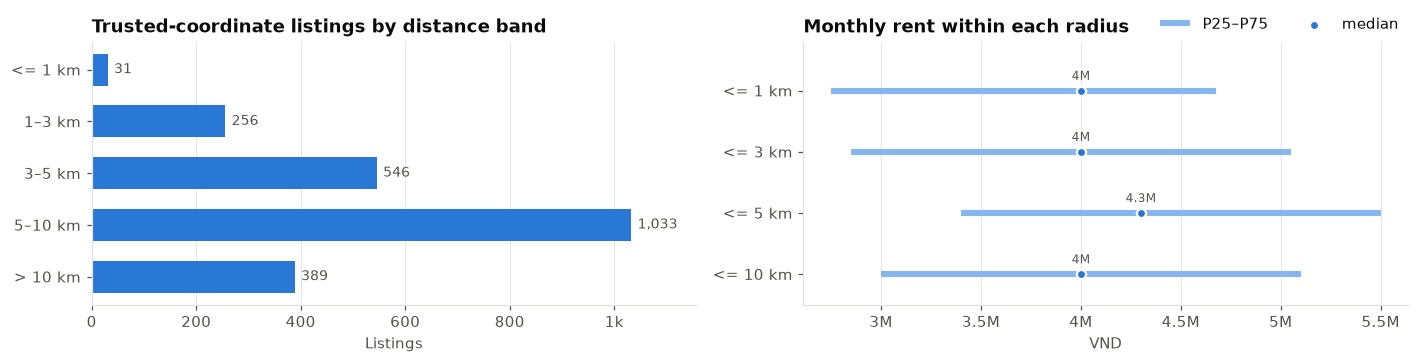

In [10]:
market_summary = summarize_radius_market(search_df, radii=[1.0, 3.0, 5.0, 10.0])
display(market_summary)

band_order = ["<= 1 km", "1–3 km", "3–5 km", "5–10 km", "> 10 km"]
band_counts = search_df["distance_band"].value_counts().reindex(band_order).dropna()
valid_market = market_summary.dropna(subset=["Median Rent (VNĐ)"]).set_index("Radius Band")

fig, (left, right) = plt.subplots(1, 2, figsize=(13, 3.4))
bar_chart(
    band_counts,
    title="Trusted-coordinate listings by distance band",
    xlabel="Listings",
    sort=False,
    ax=left,
)
range_chart(
    valid_market,
    low="P25 Rent (VNĐ)",
    mid="Median Rent (VNĐ)",
    high="P75 Rent (VNĐ)",
    title="Monthly rent within each radius",
    xlabel="VND",
    ax=right,
)
plt.tight_layout()
plt.show()

Diagnostic scatter of trusted listings within 5 km (darker = closer). It is **not** a navigational map.

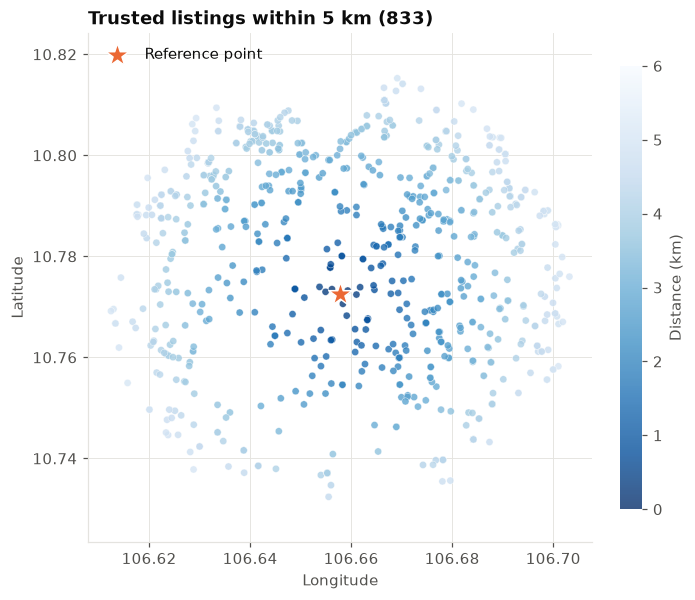

In [11]:
nearby = search_df.loc[search_df["distance_km"].le(5.0)]
fig, ax = plt.subplots(figsize=(6.5, 6))
points = ax.scatter(
    nearby["map_longitude"],
    nearby["map_latitude"],
    c=nearby["distance_km"],
    cmap="Blues_r",
    vmin=0,
    vmax=6,
    s=22,
    alpha=0.8,
    edgecolors="white",
    linewidths=0.3,
)
ax.scatter(
    REFERENCE_LONGITUDE,
    REFERENCE_LATITUDE,
    marker="*",
    s=260,
    color=CATEGORICAL[1],
    edgecolors="white",
    linewidths=1,
    zorder=5,
    label="Reference point",
)
colorbar = plt.colorbar(points, ax=ax, fraction=0.04)
colorbar.set_label("Distance (km)")
colorbar.outline.set_visible(False)
ax.set(
    title=f"Trusted listings within 5 km ({len(nearby):,})", xlabel="Longitude", ylabel="Latitude"
)
ax.set_aspect("equal", adjustable="datalim")
ax.ticklabel_format(useOffset=False)
ax.grid(axis="y")
ax.legend(loc="upper left")
plt.show()

## 10. Product readiness

> **Why:** Turn coverage evidence into a product readiness verdict.

In [12]:
readiness = evaluate_product_readiness(coverage_audit)
display(Markdown(f"### Readiness: `{readiness['verdict']}`\n\n{readiness['interpretation']}"))

### Readiness: `ADMIN_FALLBACK_READY`

RoomBeacon trusted coordinate coverage is currently limited (1.7%), while administrative ward coverage is substantial (67.7%). The platform reliably supports administrative location discovery (Same-Ward / Same-District), with exact radius retrieval operating as a high-precision but low-coverage prototype tier.

## 11. Persist analytical artifacts

> **Why:** Write CSV evidence to `data/analysis/nearby_search/`. **Tagged `skip-execution`** so a normal run stays read-only.

In [13]:
ARTIFACT_DIR = PROJECT_ROOT / "data" / "analysis" / "nearby_search"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
coverage_audit.to_csv(ARTIFACT_DIR / "location_quality_summary.csv", index=False)
funnel_df.to_csv(ARTIFACT_DIR / "search_coverage_funnel.csv", index=False)
market_summary.to_csv(ARTIFACT_DIR / "radius_market_summary.csv", index=False)
exact_results.to_csv(ARTIFACT_DIR / "nearby_search_exact_results.csv", index=False)
same_ward_results.to_csv(ARTIFACT_DIR / "same_ward_fallback_results.csv", index=False)
same_district_results.to_csv(ARTIFACT_DIR / "same_district_fallback_results.csv", index=False)
metadata = {
    "generated_at": datetime.now(timezone.utc).astimezone().isoformat(),
    "reference_location": ref_contract,
    "price_display_policy": PRICE_DISPLAY_POLICY,
    "search_parameters": {
        "radius_km": SEARCH_RADIUS_KM,
        "max_results": MAX_RESULTS,
        "min_price": MIN_PRICE,
        "max_price": MAX_PRICE,
        "min_area": MIN_AREA,
        "max_area": MAX_AREA,
    },
    "taxonomy_counts": taxonomy_counts.to_dict(),
    "coordinate_search_quality": coord_quality.to_dict(),
    "results_count": {
        "exact_distance_matches": len(exact_results),
        "same_ward_matches": len(same_ward_results),
        "same_district_matches": len(same_district_results),
    },
    "readiness": readiness,
}
(ARTIFACT_DIR / "search_run_metadata.json").write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8"
)
display(
    Markdown(
        f"Saved 6 CSV artifacts and run metadata to `{ARTIFACT_DIR.relative_to(PROJECT_ROOT)}`."
    )
)

Saved 6 CSV artifacts and run metadata to `data/analysis/nearby_search`.

## Summary

In [14]:
display(
    Markdown(
        f"""
**Key findings**

- **{len(rental_df):,}** listings are rental-compatible; **{int(trusted.Count):,}** ({trusted.Percent:.2f}%) support exact-distance search.
- For *{REFERENCE_NAME}* (radius {SEARCH_RADIUS_KM:g} km): **{len(exact_results):,}** exact-distance matches,
  **{len(same_ward_results):,}** same-ward and **{len(same_district_results):,}** same-district fallbacks.
- Ward-level coverage (**{ward.Percent:.1f}%**) makes administrative matching the main discovery path today.
- Readiness: **{readiness['verdict']}**.

**Next step:** raising trusted-coordinate coverage (e.g. a real geocoding job) is what unlocks radius search for most listings.
"""
    )
)


**Key findings**

- **131,414** listings are rental-compatible; **2,255** (1.72%) support exact-distance search.
- For *Đại học Bách Khoa TP.HCM (Campus Lý Thường Kiệt, Q.10)* (radius 3 km): **20** exact-distance matches,
  **0** same-ward and **20** same-district fallbacks.
- Ward-level coverage (**67.7%**) makes administrative matching the main discovery path today.
- Readiness: **ADMIN_FALLBACK_READY**.

**Next step:** raising trusted-coordinate coverage (e.g. a real geocoding job) is what unlocks radius search for most listings.
